# Chapter 84 - Weight Decay and AdamW

Chapter 83 regularized activations with dropout.

This chapter studies weight decay, which changes parameter updates rather than randomly masking activations.

## Learning goals

By the end of this chapter, you will be able to:

- explain decoupled weight decay in AdamW;

- distinguish weight decay from dropout and coupled L2 regularization;

- compare AdamW with decay rates `0.0` and `0.01`;

- interpret loss curves and parameter norms without treating norms as quality scores;

- explain why the effect depends on learning rate, decay rate, and update count;

- recognize underfitting from an intentionally extreme decay rate; and

- describe a parameter-group refinement that excludes biases and one-dimensional normalization parameters.

## Terms

A **parameter** is a learned tensor such as an embedding table, projection matrix, normalization scale, or bias.

An **optimizer** uses gradients to update parameters.

**Weight decay** multiplies selected parameters by a factor slightly below one during each optimizer step.

**AdamW** combines Adam's adaptive gradient update with a separate, decoupled weight-decay update.

**Underfitting** means the model does not fit even its training data well enough.

**Overfitting** means training performance improves more than held-out performance.

## The AdamW update intuition

Ignoring implementation details such as finite-precision arithmetic, a selected parameter receives a decay contribution proportional to `learning_rate * weight_decay * parameter`.

The conceptual decay-only step is `parameter = parameter * (1 - learning_rate * weight_decay)`.

AdamW applies this shrinkage separately from Adam's adaptively scaled gradient update.

By contrast, adding an L2 penalty to the loss puts a parameter-proportional term inside the gradient that Adam then rescales adaptively, so it is not generally equivalent.

In [1]:
weight = 5.0
learning_rate = 0.1
weight_decay = 0.01
decay_amount = learning_rate * weight_decay * weight
weight_after_decay = weight - decay_amount

print("Weight before:", weight)
print("Decay amount:", decay_amount)
print("Weight after conceptual decay-only step:", weight_after_decay)

assert weight_after_decay == 4.995

Weight before: 5.0
Decay amount: 0.005
Weight after conceptual decay-only step: 4.995


This example omits the Adam gradient update and exists only to isolate the decoupled shrinkage term.

## Verify decoupled shrinkage with PyTorch

A scalar with a zero gradient receives no loss-driven update, so any change comes from AdamW weight decay.

In [2]:
import torch  # noqa: I001


parameter_without_decay = torch.nn.Parameter(torch.tensor(5.0))
parameter_with_decay = torch.nn.Parameter(torch.tensor(5.0))
parameter_without_decay.grad = torch.tensor(0.0)
parameter_with_decay.grad = torch.tensor(0.0)

optimizer_without_decay = torch.optim.AdamW(
    [parameter_without_decay],
    lr=0.1,
    weight_decay=0.0,
)
optimizer_with_decay = torch.optim.AdamW(
    [parameter_with_decay],
    lr=0.1,
    weight_decay=0.01,
)
optimizer_without_decay.step()
optimizer_with_decay.step()

print("AdamW with decay 0.0:", float(parameter_without_decay.item()))
print("AdamW with decay 0.01:", float(parameter_with_decay.item()))

assert float(parameter_without_decay.item()) == 5.0
assert torch.isclose(parameter_with_decay, torch.tensor(4.995))

AdamW with decay 0.0: 5.0
AdamW with decay 0.01: 4.994999885559082


Weight decay is not a guarantee that every norm falls during task training because loss gradients can push useful parameters away from zero.

Parameter norms are therefore mechanism diagnostics, not direct measures of robustness, sensitivity, or generalization.

## Weight decay and dropout act on different objects

- Dropout randomly masks activations during training and is disabled during evaluation.

- Weight decay modifies selected parameters during optimizer steps and has no train/eval mode switch.

They can be used together, but neither replaces adequate data, model capacity, or a correct training loop.

## Build the same document holdout

Three excerpts determine the character vocabulary and training stream, while a different excerpt remains held out.

This avoids the validation leakage created by repeating one passage before a random split.

In [3]:
training_documents = [
    """Alice was beginning to get very tired of sitting by her sister on the bank,
and of having nothing to do. Once or twice she had peeped into the book her
sister was reading, but it had no pictures or conversations in it, and what is
the use of a book, thought Alice, without pictures or conversation?""",
    """So she was considering in her own mind, as well as she could, for the hot day
made her feel very sleepy and stupid, whether the pleasure of making a daisy
chain would be worth the trouble of getting up and picking the daisies, when
suddenly a white rabbit with pink eyes ran close by her.""",
    """There was nothing so very remarkable in that; nor did Alice think it so very
much out of the way to hear the rabbit say to itself, Oh dear! Oh dear! I shall
be too late! But when the rabbit actually took a watch out of its waistcoat
pocket, and looked at it, and then hurried on, Alice started to her feet.""",
]
validation_text = """The rabbit hole went straight on like a tunnel for some way,
and then dipped suddenly down, so suddenly that Alice had not a moment to think
about stopping herself before she found herself falling down what seemed to be
a very deep well."""

training_text = "\n\n".join(training_documents)
characters = sorted(set(training_text))
character_to_id = {character: token_id for token_id, character in enumerate(characters)}
id_to_character = {
    token_id: character for character, token_id in character_to_id.items()
}


def encode_text(text: str) -> list[int]:
    unknown_characters = sorted(set(text) - set(character_to_id))
    if unknown_characters:
        raise ValueError(f"Unknown characters: {unknown_characters!r}.")
    return [character_to_id[character] for character in text]


def decode_token_ids(token_ids: list[int]) -> str:
    return "".join(id_to_character[token_id] for token_id in token_ids)


training_token_ids = torch.tensor(encode_text(training_text), dtype=torch.long)
validation_token_ids = torch.tensor(encode_text(validation_text), dtype=torch.long)
vocabulary_size = len(characters)
device = "cpu"

print("Device:", device)
print("Vocabulary size:", vocabulary_size)
print("Training tokens:", training_token_ids.numel())
print("Validation tokens:", validation_token_ids.numel())

assert decode_token_ids(validation_token_ids.tolist()) == validation_text

Device: cpu
Vocabulary size: 35
Training tokens: 896
Validation tokens: 237


## Build reproducible GPT batches

Explicit random generators let all decay settings receive identical token windows.

In [4]:
def get_gpt_training_batch(
    token_ids: torch.Tensor,
    batch_size: int,
    context_length: int,
    generator: torch.Generator,
) -> tuple[torch.Tensor, torch.Tensor]:
    if token_ids.ndim != 1:
        raise ValueError("token_ids must be one-dimensional.")
    number_of_valid_starts = token_ids.numel() - context_length
    if number_of_valid_starts < 1:
        raise ValueError("Token stream must be longer than context_length.")
    start_indexes = torch.randint(
        0,
        number_of_valid_starts,
        (batch_size,),
        generator=generator,
    )
    offsets = torch.arange(context_length)
    input_indexes = start_indexes[:, None] + offsets[None, :]
    return token_ids[input_indexes], token_ids[input_indexes + 1]


test_generator = torch.Generator().manual_seed(84)
test_inputs, test_targets = get_gpt_training_batch(
    training_token_ids,
    batch_size=4,
    context_length=16,
    generator=test_generator,
)

print("Input shape:", tuple(test_inputs.shape))
print("Target shift correct:", torch.equal(test_targets[:, :-1], test_inputs[:, 1:]))

assert torch.equal(test_targets[:, :-1], test_inputs[:, 1:])

Input shape: (4, 16)
Target shift correct: True


## Reuse the dropout-aware TinyGPT architecture

The architecture matches Chapter 83 so weight decay is the only experimental change.

Both dropout masks and batches are reset to the same seeds for each run.

In [5]:
import math  # noqa: I001


class MultiHeadCausalSelfAttention(torch.nn.Module):
    embedding_dimension: int
    number_of_attention_heads: int
    head_size: int

    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
        context_length: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        if embedding_dimension % number_of_attention_heads != 0:
            raise ValueError("Attention heads must divide the embedding dimension.")
        if not 0.0 <= dropout_rate < 1.0:
            raise ValueError("dropout_rate must be in [0, 1).")

        self.embedding_dimension = embedding_dimension
        self.number_of_attention_heads = number_of_attention_heads
        self.head_size = embedding_dimension // number_of_attention_heads
        self.query_projection = torch.nn.Linear(
            embedding_dimension,
            embedding_dimension,
            bias=False,
        )
        self.key_projection = torch.nn.Linear(
            embedding_dimension,
            embedding_dimension,
            bias=False,
        )
        self.value_projection = torch.nn.Linear(
            embedding_dimension,
            embedding_dimension,
            bias=False,
        )
        self.output_projection = torch.nn.Linear(
            embedding_dimension,
            embedding_dimension,
        )
        self.attention_dropout = torch.nn.Dropout(dropout_rate)
        self.output_dropout = torch.nn.Dropout(dropout_rate)
        self.register_buffer(
            "causal_mask",
            torch.tril(torch.ones(context_length, context_length, dtype=torch.bool)),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        batch_size, sequence_length, _ = input_values.shape

        def split_heads(values: torch.Tensor) -> torch.Tensor:
            return values.view(
                batch_size,
                sequence_length,
                self.number_of_attention_heads,
                self.head_size,
            ).transpose(1, 2)

        queries = split_heads(self.query_projection(input_values))
        keys = split_heads(self.key_projection(input_values))
        values = split_heads(self.value_projection(input_values))
        attention_scores = queries @ keys.transpose(-2, -1)
        attention_scores = attention_scores / math.sqrt(self.head_size)
        causal_mask = self.causal_mask[:sequence_length, :sequence_length]
        attention_scores = attention_scores.masked_fill(
            ~causal_mask,
            float("-inf"),
        )
        attention_weights = torch.softmax(attention_scores, dim=-1)
        dropped_attention_weights = self.attention_dropout(attention_weights)
        attended_values = dropped_attention_weights @ values
        concatenated_values = (
            attended_values.transpose(1, 2)
            .contiguous()
            .view(
                batch_size,
                sequence_length,
                self.embedding_dimension,
            )
        )
        projected_values = self.output_projection(concatenated_values)
        output_values: torch.Tensor = self.output_dropout(projected_values)
        return output_values

In [6]:
class FeedForwardNetwork(torch.nn.Module):
    def __init__(self, embedding_dimension: int, dropout_rate: float) -> None:
        super().__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(embedding_dimension, 4 * embedding_dimension),
            torch.nn.ReLU(),
            torch.nn.Linear(4 * embedding_dimension, embedding_dimension),
            torch.nn.Dropout(dropout_rate),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        output_values: torch.Tensor = self.network(input_values)
        return output_values


class TransformerBlock(torch.nn.Module):
    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
        context_length: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        self.attention_norm = torch.nn.LayerNorm(embedding_dimension)
        self.attention = MultiHeadCausalSelfAttention(
            embedding_dimension=embedding_dimension,
            number_of_attention_heads=number_of_attention_heads,
            context_length=context_length,
            dropout_rate=dropout_rate,
        )
        self.feedforward_norm = torch.nn.LayerNorm(embedding_dimension)
        self.feedforward = FeedForwardNetwork(
            embedding_dimension=embedding_dimension,
            dropout_rate=dropout_rate,
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        attention_branch = self.attention(self.attention_norm(input_values))
        values_after_attention = input_values + attention_branch
        feedforward_branch = self.feedforward(
            self.feedforward_norm(values_after_attention)
        )
        output_values: torch.Tensor = values_after_attention + feedforward_branch
        return output_values

In [7]:
class TinyGPT(torch.nn.Module):
    vocabulary_size: int
    context_length: int
    dropout_rate: float

    def __init__(
        self,
        vocabulary_size: int,
        context_length: int,
        embedding_dimension: int,
        number_of_attention_heads: int,
        number_of_transformer_blocks: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        if not 0.0 <= dropout_rate < 1.0:
            raise ValueError("dropout_rate must be in [0, 1).")
        self.vocabulary_size = vocabulary_size
        self.context_length = context_length
        self.dropout_rate = dropout_rate
        self.token_embedding = torch.nn.Embedding(
            vocabulary_size,
            embedding_dimension,
        )
        self.position_embedding = torch.nn.Embedding(
            context_length,
            embedding_dimension,
        )
        self.embedding_dropout = torch.nn.Dropout(dropout_rate)
        self.transformer_blocks = torch.nn.ModuleList(
            [
                TransformerBlock(
                    embedding_dimension=embedding_dimension,
                    number_of_attention_heads=number_of_attention_heads,
                    context_length=context_length,
                    dropout_rate=dropout_rate,
                )
                for _ in range(number_of_transformer_blocks)
            ]
        )
        self.final_norm = torch.nn.LayerNorm(embedding_dimension)
        self.output_layer = torch.nn.Linear(embedding_dimension, vocabulary_size)

    def forward(
        self,
        input_token_ids: torch.Tensor,
        target_token_ids: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        if input_token_ids.ndim != 2:
            raise ValueError("Inputs must have shape [batch, time].")
        batch_size, sequence_length = input_token_ids.shape
        if sequence_length > self.context_length:
            raise ValueError("Input exceeds model context length.")

        position_ids = torch.arange(sequence_length, device=input_token_ids.device)
        hidden_values = self.token_embedding(input_token_ids)
        hidden_values = hidden_values + self.position_embedding(position_ids)
        hidden_values = self.embedding_dropout(hidden_values)
        for transformer_block in self.transformer_blocks:
            hidden_values = transformer_block(hidden_values)
        logits = self.output_layer(self.final_norm(hidden_values))

        loss = None
        if target_token_ids is not None:
            if target_token_ids.shape != input_token_ids.shape:
                raise ValueError("Targets must have the same shape as inputs.")
            loss = torch.nn.functional.cross_entropy(
                logits.reshape(batch_size * sequence_length, self.vocabulary_size),
                target_token_ids.reshape(batch_size * sequence_length),
            )
        return logits, loss

    @torch.no_grad()
    def generate(
        self,
        input_token_ids: torch.Tensor,
        number_of_new_tokens: int,
        generator: torch.Generator,
        temperature: float = 1.0,
        top_k: int | None = None,
    ) -> torch.Tensor:
        if temperature <= 0:
            raise ValueError("temperature must be positive.")
        generated_ids = input_token_ids
        for _ in range(number_of_new_tokens):
            model_input = generated_ids[:, -self.context_length :]
            logits, _ = self(model_input)
            next_logits = logits[:, -1, :] / temperature
            if top_k is not None:
                effective_top_k = min(top_k, self.vocabulary_size)
                top_values, _ = torch.topk(next_logits, effective_top_k)
                next_logits = next_logits.masked_fill(
                    next_logits < top_values[:, -1, None],
                    float("-inf"),
                )
            probabilities = torch.softmax(next_logits, dim=-1)
            next_ids = torch.multinomial(
                probabilities,
                num_samples=1,
                generator=generator,
            )
            generated_ids = torch.cat([generated_ids, next_ids], dim=1)
        return generated_ids

## Configure the comparison

The requested main settings are AdamW with decay `0.0` and `0.01` for exactly 800 optimizer updates.

An intentionally extreme `10.0` run is included only as an underfitting stress test.

In [8]:
from typing import TypedDict


class WeightDecayConfig(TypedDict):
    context_length: int
    embedding_dimension: int
    number_of_attention_heads: int
    number_of_transformer_blocks: int
    dropout_rate: float
    batch_size: int
    learning_rate: float
    training_steps: int
    evaluation_interval: int
    evaluation_batches: int


weight_decay_config: WeightDecayConfig = {
    "context_length": 64,
    "embedding_dimension": 64,
    "number_of_attention_heads": 4,
    "number_of_transformer_blocks": 2,
    "dropout_rate": 0.1,
    "batch_size": 8,
    "learning_rate": 0.0003,
    "training_steps": 800,
    "evaluation_interval": 100,
    "evaluation_batches": 8,
}

print(weight_decay_config)

{'context_length': 64, 'embedding_dimension': 64, 'number_of_attention_heads': 4, 'number_of_transformer_blocks': 2, 'dropout_rate': 0.1, 'batch_size': 8, 'learning_rate': 0.0003, 'training_steps': 800, 'evaluation_interval': 100, 'evaluation_batches': 8}


## Why the rate alone is incomplete

With no gradient, repeated AdamW shrinkage is approximately `(1 - learning_rate * weight_decay) ** updates`.

This calculation explains why `0.5` is not automatically extreme under a small learning rate and short run.

In [9]:
for decay_rate in [0.0, 0.01, 0.5, 10.0]:
    shrinkage_factor = (
        1.0 - weight_decay_config["learning_rate"] * decay_rate
    ) ** weight_decay_config["training_steps"]
    print(
        f"decay={decay_rate:>5} | decay-only multiplier after 800 steps: "
        f"{shrinkage_factor:.6f}"
    )

decay=  0.0 | decay-only multiplier after 800 steps: 1.000000
decay= 0.01 | decay-only multiplier after 800 steps: 0.997603
decay=  0.5 | decay-only multiplier after 800 steps: 0.886912
decay= 10.0 | decay-only multiplier after 800 steps: 0.090391


The calculation isolates decay and does not predict the final trained norm because task gradients act at every update.

## Measure parameter norms carefully

The total L2 norm summarizes all trainable tensors in one number, while the root-mean-square value also accounts for the fixed parameter count.

In [10]:
def compute_parameter_statistics(model: torch.nn.Module) -> tuple[float, float]:
    squared_sum = sum(
        float(parameter.detach().square().sum().item())
        for parameter in model.parameters()
    )
    parameter_count = sum(parameter.numel() for parameter in model.parameters())
    total_l2_norm = math.sqrt(squared_sum)
    root_mean_square = math.sqrt(squared_sum / parameter_count)
    return total_l2_norm, root_mean_square

## Evaluate fixed batches in evaluation mode

Checkpoint losses disable dropout and reuse identical sampled batches across checkpoints and decay settings.

In [11]:
@torch.no_grad()
def estimate_split_losses(
    model: TinyGPT,
    config: WeightDecayConfig,
    seed: int,
) -> dict[str, float]:
    was_training = model.training
    model.eval()
    mean_losses: dict[str, float] = {}

    for split_offset, (split_name, split_ids) in enumerate(
        [("train", training_token_ids), ("validation", validation_token_ids)]
    ):
        evaluation_generator = torch.Generator().manual_seed(seed + split_offset)
        split_losses: list[float] = []
        for _ in range(config["evaluation_batches"]):
            input_batch, target_batch = get_gpt_training_batch(
                split_ids,
                batch_size=config["batch_size"],
                context_length=config["context_length"],
                generator=evaluation_generator,
            )
            _, loss = model(input_batch, target_batch)
            if loss is None or not torch.isfinite(loss):
                raise RuntimeError("Evaluation produced a non-finite loss.")
            split_losses.append(float(loss.item()))
        mean_losses[split_name] = sum(split_losses) / len(split_losses)

    model.train(was_training)
    return mean_losses

## Train with configurable AdamW decay

The optimizer applies the chosen decay to all trainable parameters for this introductory experiment.

The loop evaluates at step 0 and after update 800 without taking an extra update.

In [12]:
from dataclasses import dataclass


@dataclass
class WeightDecayResult:
    model: TinyGPT
    weight_decay: float
    evaluation_steps: list[int]
    training_losses: list[float]
    validation_losses: list[float]
    total_norms: list[float]
    root_mean_square_values: list[float]
    optimizer_updates: int


def train_model_with_weight_decay(
    weight_decay: float,
    config: WeightDecayConfig,
    model_seed: int,
    training_seed: int,
    evaluation_seed: int,
) -> WeightDecayResult:
    if weight_decay < 0:
        raise ValueError("weight_decay must be nonnegative.")

    torch.manual_seed(model_seed)
    model = TinyGPT(
        vocabulary_size=vocabulary_size,
        context_length=config["context_length"],
        embedding_dimension=config["embedding_dimension"],
        number_of_attention_heads=config["number_of_attention_heads"],
        number_of_transformer_blocks=config["number_of_transformer_blocks"],
        dropout_rate=config["dropout_rate"],
    )
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=weight_decay,
    )
    training_generator = torch.Generator().manual_seed(training_seed)
    evaluation_steps: list[int] = []
    training_losses: list[float] = []
    validation_losses: list[float] = []
    total_norms: list[float] = []
    root_mean_square_values: list[float] = []

    def record_checkpoint(step: int) -> None:
        losses = estimate_split_losses(model, config, seed=evaluation_seed)
        total_norm, root_mean_square = compute_parameter_statistics(model)
        evaluation_steps.append(step)
        training_losses.append(losses["train"])
        validation_losses.append(losses["validation"])
        total_norms.append(total_norm)
        root_mean_square_values.append(root_mean_square)
        print(
            f"decay {weight_decay:>5} | step {step:>3} | "
            f"train-split loss {losses['train']:.4f} | "
            f"validation loss {losses['validation']:.4f} | "
            f"parameter RMS {root_mean_square:.5f}"
        )

    torch.manual_seed(training_seed)
    model.train()
    record_checkpoint(step=0)

    optimizer_updates = 0
    for step in range(1, config["training_steps"] + 1):
        input_batch, target_batch = get_gpt_training_batch(
            training_token_ids,
            batch_size=config["batch_size"],
            context_length=config["context_length"],
            generator=training_generator,
        )
        logits, loss = model(input_batch, target_batch)
        if logits.shape[-1] != vocabulary_size:
            raise RuntimeError("Logit dimension does not match vocabulary size.")
        if loss is None or not torch.isfinite(loss):
            raise RuntimeError("Training produced a non-finite loss.")
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        optimizer_updates += 1

        if step % config["evaluation_interval"] == 0:
            record_checkpoint(step)

    if optimizer_updates != config["training_steps"]:
        raise RuntimeError("Incorrect optimizer-update count.")
    return WeightDecayResult(
        model=model,
        weight_decay=weight_decay,
        evaluation_steps=evaluation_steps,
        training_losses=training_losses,
        validation_losses=validation_losses,
        total_norms=total_norms,
        root_mean_square_values=root_mean_square_values,
        optimizer_updates=optimizer_updates,
    )

## Train with no weight decay

AdamW with `weight_decay=0.0` supplies the adaptive optimizer baseline.

In [13]:
no_weight_decay_result = train_model_with_weight_decay(
    weight_decay=0.0,
    config=weight_decay_config,
    model_seed=8401,
    training_seed=8402,
    evaluation_seed=8403,
)

decay   0.0 | step   0 | train-split loss 3.6790 | validation loss 3.6411 | parameter RMS 0.25550


decay   0.0 | step 100 | train-split loss 2.6387 | validation loss 2.8011 | parameter RMS 0.25550


decay   0.0 | step 200 | train-split loss 2.3634 | validation loss 2.6792 | parameter RMS 0.25552


decay   0.0 | step 300 | train-split loss 2.2360 | validation loss 2.6395 | parameter RMS 0.25562


decay   0.0 | step 400 | train-split loss 2.1621 | validation loss 2.6213 | parameter RMS 0.25577


decay   0.0 | step 500 | train-split loss 2.1067 | validation loss 2.6113 | parameter RMS 0.25592


decay   0.0 | step 600 | train-split loss 2.0571 | validation loss 2.6034 | parameter RMS 0.25608


decay   0.0 | step 700 | train-split loss 2.0046 | validation loss 2.6022 | parameter RMS 0.25622


decay   0.0 | step 800 | train-split loss 1.9538 | validation loss 2.6277 | parameter RMS 0.25634


## Train with weight decay `0.01`

This run changes only the `weight_decay` argument in the required AdamW call.

In [14]:
with_weight_decay_result = train_model_with_weight_decay(
    weight_decay=0.01,
    config=weight_decay_config,
    model_seed=8401,
    training_seed=8402,
    evaluation_seed=8403,
)

decay  0.01 | step   0 | train-split loss 3.6790 | validation loss 3.6411 | parameter RMS 0.25550


decay  0.01 | step 100 | train-split loss 2.6389 | validation loss 2.8012 | parameter RMS 0.25542


decay  0.01 | step 200 | train-split loss 2.3636 | validation loss 2.6793 | parameter RMS 0.25537


decay  0.01 | step 300 | train-split loss 2.2363 | validation loss 2.6394 | parameter RMS 0.25539


decay  0.01 | step 400 | train-split loss 2.1625 | validation loss 2.6212 | parameter RMS 0.25546


decay  0.01 | step 500 | train-split loss 2.1073 | validation loss 2.6111 | parameter RMS 0.25554


decay  0.01 | step 600 | train-split loss 2.0577 | validation loss 2.6031 | parameter RMS 0.25562


decay  0.01 | step 700 | train-split loss 2.0052 | validation loss 2.6018 | parameter RMS 0.25570


decay  0.01 | step 800 | train-split loss 1.9545 | validation loss 2.6274 | parameter RMS 0.25574


## Run an extreme-decay stress test

`10.0` is intentionally excessive here and exists to make underfitting visible, not as a recommended setting.

In [15]:
extreme_weight_decay_result = train_model_with_weight_decay(
    weight_decay=10.0,
    config=weight_decay_config,
    model_seed=8401,
    training_seed=8402,
    evaluation_seed=8403,
)

decay  10.0 | step   0 | train-split loss 3.6790 | validation loss 3.6411 | parameter RMS 0.25550


decay  10.0 | step 100 | train-split loss 2.8454 | validation loss 2.9345 | parameter RMS 0.18923


decay  10.0 | step 200 | train-split loss 2.7464 | validation loss 2.8721 | parameter RMS 0.14016


decay  10.0 | step 300 | train-split loss 2.7182 | validation loss 2.8448 | parameter RMS 0.10407


decay  10.0 | step 400 | train-split loss 2.7297 | validation loss 2.8517 | parameter RMS 0.07764


decay  10.0 | step 500 | train-split loss 2.7512 | validation loss 2.8661 | parameter RMS 0.05834


decay  10.0 | step 600 | train-split loss 2.7780 | validation loss 2.8874 | parameter RMS 0.04433


decay  10.0 | step 700 | train-split loss 2.8014 | validation loss 2.9040 | parameter RMS 0.03427


decay  10.0 | step 800 | train-split loss 2.8225 | validation loss 2.9220 | parameter RMS 0.02714


## Plot losses and parameter scale

The first panel is the required `0.0` versus `0.01` loss comparison.

The other panels show mechanism and stress-test diagnostics without treating a smaller norm as a better model.

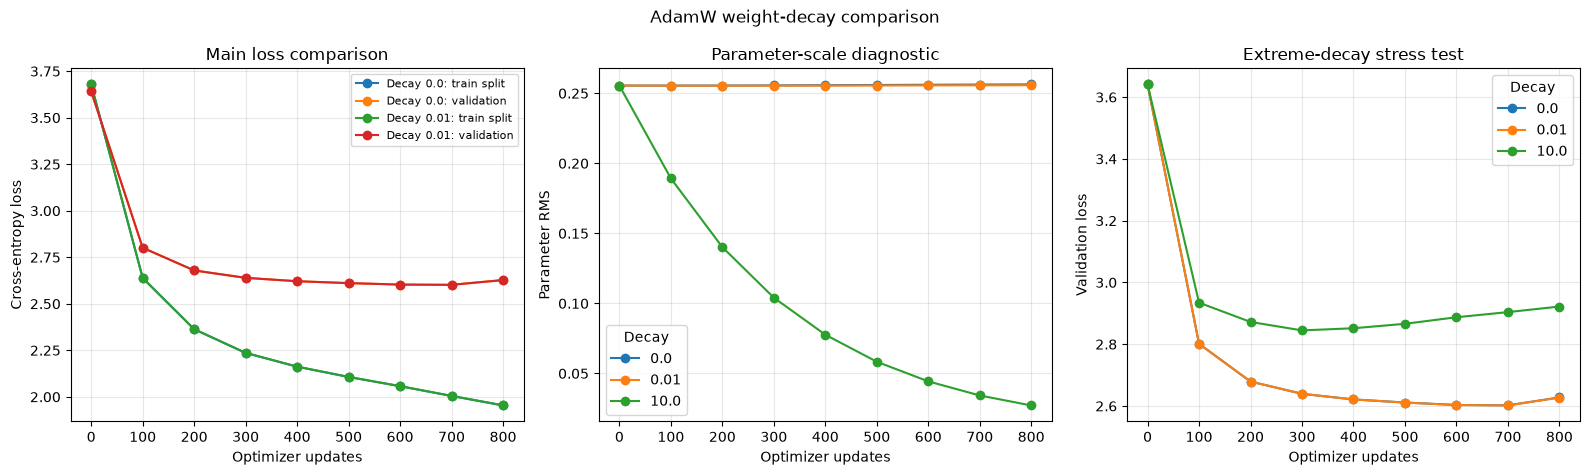

In [16]:
import matplotlib.pyplot as plt  # noqa: I001


figure, axes = plt.subplots(1, 3, figsize=(16, 4.8))
axes[0].plot(
    no_weight_decay_result.evaluation_steps,
    no_weight_decay_result.training_losses,
    marker="o",
    label="Decay 0.0: train split",
)
axes[0].plot(
    no_weight_decay_result.evaluation_steps,
    no_weight_decay_result.validation_losses,
    marker="o",
    label="Decay 0.0: validation",
)
axes[0].plot(
    with_weight_decay_result.evaluation_steps,
    with_weight_decay_result.training_losses,
    marker="o",
    label="Decay 0.01: train split",
)
axes[0].plot(
    with_weight_decay_result.evaluation_steps,
    with_weight_decay_result.validation_losses,
    marker="o",
    label="Decay 0.01: validation",
)
axes[0].set_xlabel("Optimizer updates")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].set_title("Main loss comparison")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

for result, label in [
    (no_weight_decay_result, "0.0"),
    (with_weight_decay_result, "0.01"),
    (extreme_weight_decay_result, "10.0"),
]:
    axes[1].plot(
        result.evaluation_steps,
        result.root_mean_square_values,
        marker="o",
        label=label,
    )
axes[1].set_xlabel("Optimizer updates")
axes[1].set_ylabel("Parameter RMS")
axes[1].set_title("Parameter-scale diagnostic")
axes[1].legend(title="Decay")
axes[1].grid(alpha=0.3)

for result, label in [
    (no_weight_decay_result, "0.0"),
    (with_weight_decay_result, "0.01"),
    (extreme_weight_decay_result, "10.0"),
]:
    axes[2].plot(
        result.evaluation_steps,
        result.validation_losses,
        marker="o",
        label=label,
    )
axes[2].set_xlabel("Optimizer updates")
axes[2].set_ylabel("Validation loss")
axes[2].set_title("Extreme-decay stress test")
axes[2].legend(title="Decay")
axes[2].grid(alpha=0.3)

figure.suptitle("AdamW weight-decay comparison")
figure.tight_layout()
plt.show()

## Summarize final and best checkpoints

Best validation loss prevents the final checkpoint alone from deciding the comparison.

In [17]:
print(
    "decay | final train | final validation | final gap | "
    "best validation (step) | final RMS"
)
print("-" * 100)
for result in [
    no_weight_decay_result,
    with_weight_decay_result,
    extreme_weight_decay_result,
]:
    best_index = min(
        range(len(result.validation_losses)),
        key=result.validation_losses.__getitem__,
    )
    final_gap = result.validation_losses[-1] - result.training_losses[-1]
    print(
        f"{result.weight_decay:>5} | {result.training_losses[-1]:>11.4f} | "
        f"{result.validation_losses[-1]:>16.4f} | {final_gap:>9.4f} | "
        f"{result.validation_losses[best_index]:.4f} "
        f"({result.evaluation_steps[best_index]:>3}) | "
        f"{result.root_mean_square_values[-1]:.5f}"
    )

decay | final train | final validation | final gap | best validation (step) | final RMS
----------------------------------------------------------------------------------------------------
  0.0 |      1.9538 |           2.6277 |    0.6739 | 2.6022 (700) | 0.25634
 0.01 |      1.9545 |           2.6274 |    0.6729 | 2.6018 (700) | 0.25574
 10.0 |      2.8225 |           2.9220 |    0.0995 | 2.8448 (300) | 0.02714


In this run, decay `0.01` produces a slightly lower parameter RMS but nearly identical training and validation losses to decay `0.0`.

Its best validation loss differs by less than one thousandth, which is not persuasive evidence of a quality improvement from one seed.

The extreme run drives parameter RMS sharply downward while keeping absolute training and validation losses high, which demonstrates underfitting.

Its small final train-validation gap is not a success because both losses are poor.

## Generate from the two main models

Weight decay has already acted during optimization, so generation needs no weight-decay switch.

The models still contain dropout, which is disabled with evaluation mode before sampling.

In [18]:
@torch.no_grad()
def generate_character_text(
    model: TinyGPT,
    prompt: str,
    number_of_new_tokens: int,
    sampling_seed: int,
) -> str:
    was_training = model.training
    model.eval()
    generated_ids = model.generate(
        torch.tensor([encode_text(prompt)], dtype=torch.long),
        number_of_new_tokens=number_of_new_tokens,
        generator=torch.Generator().manual_seed(sampling_seed),
        temperature=1.0,
        top_k=10,
    )
    model.train(was_training)
    return decode_token_ids(generated_ids[0].tolist())


no_decay_sample = generate_character_text(
    no_weight_decay_result.model,
    prompt="Alice",
    number_of_new_tokens=160,
    sampling_seed=8410,
)
decay_sample = generate_character_text(
    with_weight_decay_result.model,
    prompt="Alice",
    number_of_new_tokens=160,
    sampling_seed=8410,
)

print("NO WEIGHT DECAY")
print(no_decay_sample)
print()
print("WEIGHT DECAY 0.01")
print(decay_sample)

NO WEIGHT DECAY
Alice is o besy sof okising, ay or her beror

Tthin wather ons t sabiteso wan ted her! tthen r d sist icherye d, ad ad helofere der! wang oule pinldar wnon thtos pin

WEIGHT DECAY 0.01
Alice is o besy sof okising, ay or her beror

Tthin wather ons t sabiteso wan ted her! tthen r d sist icherye d, ad ad helofere der! wang oule pinldar wnon thtos pin


One sampled string is not a reliable quality metric, so the held-out loss history remains the primary comparison.

The two retained samples are identical under this seed because the modest decay changed the learned distribution too little to alter these sampled choices.

## Refine which parameters decay

The main experiment intentionally uses `model.parameters()` to teach the required optimizer line.

A common refinement decays matrices such as linear and embedding weights while excluding one-dimensional normalization scales and biases.

This dimensionality policy is explicit and more robust than searching parameter names for a particular normalization spelling.

In [19]:
def create_grouped_adamw_optimizer(
    model: torch.nn.Module,
    learning_rate: float,
    weight_decay: float,
) -> torch.optim.AdamW:
    decay_parameters: list[torch.nn.Parameter] = []
    no_decay_parameters: list[torch.nn.Parameter] = []

    for parameter in model.parameters():
        if not parameter.requires_grad:
            continue
        if parameter.ndim >= 2:
            decay_parameters.append(parameter)
        else:
            no_decay_parameters.append(parameter)

    return torch.optim.AdamW(
        [
            {"params": decay_parameters, "weight_decay": weight_decay},
            {"params": no_decay_parameters, "weight_decay": 0.0},
        ],
        lr=learning_rate,
    )


grouped_optimizer = create_grouped_adamw_optimizer(
    with_weight_decay_result.model,
    learning_rate=weight_decay_config["learning_rate"],
    weight_decay=0.01,
)
grouped_parameter_ids = [
    id(parameter)
    for parameter_group in grouped_optimizer.param_groups
    for parameter in parameter_group["params"]
]
model_parameter_ids = [
    id(parameter)
    for parameter in with_weight_decay_result.model.parameters()
    if parameter.requires_grad
]

print("Decay-group tensors:", len(grouped_optimizer.param_groups[0]["params"]))
print("No-decay-group tensors:", len(grouped_optimizer.param_groups[1]["params"]))
print(
    "Group decay rates:",
    [group["weight_decay"] for group in grouped_optimizer.param_groups],
)

assert len(grouped_parameter_ids) == len(set(grouped_parameter_ids))
assert set(grouped_parameter_ids) == set(model_parameter_ids)

Decay-group tensors: 15
No-decay-group tensors: 17
Group decay rates: [0.01, 0.0]


The parameter-group policy is common rather than universal, and changing it creates a different experiment from the all-parameter comparison above.

## Decide whether weight decay helps

Look for validation improvement without an unacceptable rise in train-split loss.

A smaller parameter norm confirms shrinkage pressure but does not establish better generalization.

If training loss remains high, first investigate underfitting, learning rate, update count, model capacity, batching, and data quality before increasing regularization.

Weight decay cannot teach patterns absent from the dataset or repair a mismatched tokenizer.

## Verify experiment contracts

The final assertions cover update counts, checkpoints, finite metrics, matching model shapes, and held-out reconstruction.

In [20]:
expected_steps = list(range(0, 801, 100))
results = [
    no_weight_decay_result,
    with_weight_decay_result,
    extreme_weight_decay_result,
]

for result in results:
    assert result.optimizer_updates == 800
    assert result.evaluation_steps == expected_steps
    assert all(math.isfinite(loss) for loss in result.training_losses)
    assert all(math.isfinite(loss) for loss in result.validation_losses)
    assert all(math.isfinite(norm) for norm in result.total_norms)
    assert result.model.vocabulary_size == vocabulary_size

assert decode_token_ids(validation_token_ids.tolist()) == validation_text
assert (
    no_weight_decay_result.root_mean_square_values[0]
    == (with_weight_decay_result.root_mean_square_values[0])
)
assert (
    no_weight_decay_result.root_mean_square_values[0]
    == (extreme_weight_decay_result.root_mean_square_values[0])
)

print("Exact 800-update runs: passed")
print("Finite checkpoint metrics: passed")
print("Identical initial parameter scale: passed")
print("Tokenizer/model vocabulary alignment: passed")
print("Held-out round trip: passed")

Exact 800-update runs: passed
Finite checkpoint metrics: passed
Identical initial parameter scale: passed
Tokenizer/model vocabulary alignment: passed
Held-out round trip: passed


## Common mistakes

- Repeating one passage before a random split leaks content into validation and invalidates the regularization comparison.

- Comparing models with different initializations, batches, or dropout masks adds avoidable noise.

- Treating the decay rate without its learning rate and update count misstates the strength of shrinkage.

- Assuming every parameter norm must decrease ignores task gradients that can oppose decay.

- Treating a smaller norm or smaller validation gap as sufficient ignores absolute held-out loss.

- Applying decay to all parameters and describing the result as the parameter-group convention confuses two different setups.

- Taking an optimizer step after the final checkpoint silently creates 801 updates.

- Expecting weight decay to replace data, capacity, or correct preprocessing asks regularization to solve the wrong problem.

## Takeaways

- AdamW separates adaptive gradient updates from parameter-proportional shrinkage.

- The conceptual decay-only factor per update is `1 - learning_rate * weight_decay`.

- The main experiment compares the required all-parameter AdamW calls at decay `0.0` and `0.01`.

- Identical initialization, batches, dropout seeds, evaluation batches, and update counts make the comparison interpretable.

- Parameter norms reveal shrinkage pressure but do not directly measure quality or sensitivity.

- An extreme decay rate can produce underfitting, while a modest rate may have only a subtle effect in a short run.

- Production-style parameter groups commonly exclude biases and one-dimensional normalization parameters from decay.

- Validation loss, not weight magnitude alone, determines whether decay helped a particular setup.

## What comes next

Weight decay controls parameter growth, while gradient clipping limits unusually large update signals and learning-rate schedules change update size over time.

Those mechanisms address different training behaviors and should be tested in similarly controlled experiments.